# 📊 Model Performance Visualizations
This notebook trains the same Logistic Regression pipeline from `train.ipynb` and then produces detailed visualizations showing how the model performs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

# Dark style for all plots
plt.style.use('dark_background')
COLORS = {'Easy': '#1f8b4c', 'Medium': '#d4a017', 'Hard': '#b02a37'}
CLASS_COLORS = ['#1f8b4c', '#d4a017', '#b02a37']

## 1. Load Data & Train Model

In [2]:
df = pd.read_csv('../data/5000_dataset_genai.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (5000, 7)
Columns: ['question_id', 'question_text', 'topic', 'average_score', 'correct_rate', 'score_variance', 'difficulty_label']


,question_id,question_text,topic,average_score,correct_rate,score_variance,difficulty_label
0,1,Explain the data normalization in Chemistry wi...,Chemistry,8.09,0.825,1.964,Easy
1,2,Compute the key assumption in Data Structures ...,Data Structures,4.00,0.604,0.812,Medium
2,3,Analyze the logical equivalence in Biology wit...,Biology,1.11,0.117,1.702,Hard
3,4,Analyze the space complexity in Genetics with ...,Genetics,5.43,0.892,2.440,Easy
4,5,Explain the fundamental theorem in Discrete Ma...,Discrete Mathematics,4.68,0.683,0.864,Medium


In [3]:
X = df[['question_text', 'average_score', 'correct_rate', 'score_variance']]
y = df['difficulty_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(max_features=3000), 'question_text'),
    ('num', StandardScaler(), ['average_score', 'correct_rate', 'score_variance'])
])

model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
classes = model.classes_

print('Training complete.')
print(f'Classes: {classes}')

Training complete.
Classes: ['Easy' 'Hard' 'Medium']


## 2. Overall Metrics Summary

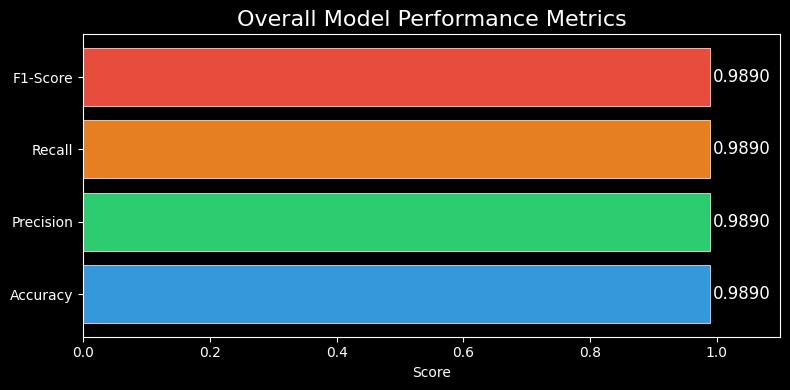

              precision    recall  f1-score   support

        Easy       0.99      1.00      0.99       334
        Hard       0.99      0.99      0.99       333
      Medium       0.99      0.98      0.98       333

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [4]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'],
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=12, color='white')
ax.set_xlim(0, 1.1)
ax.set_title('Overall Model Performance Metrics', fontsize=16)
ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

## 3. Confusion Matrix (Heatmap)

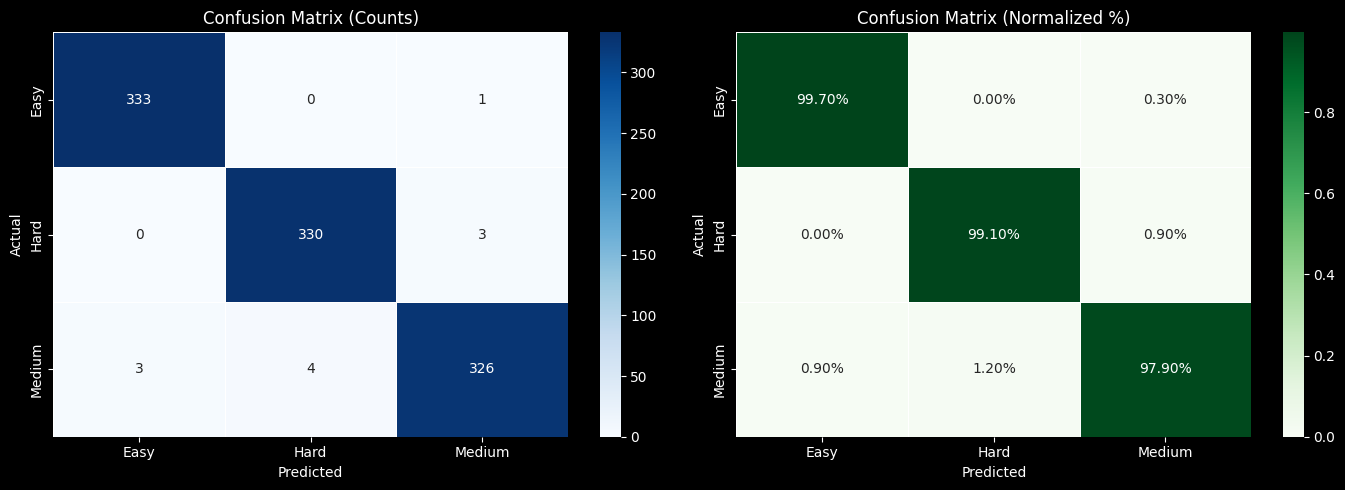

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', xticklabels=classes, yticklabels=classes,
            cmap='Greens', ax=axes[1], linewidths=0.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized %)')

plt.tight_layout()
plt.show()

## 4. Per-Class Precision, Recall & F1

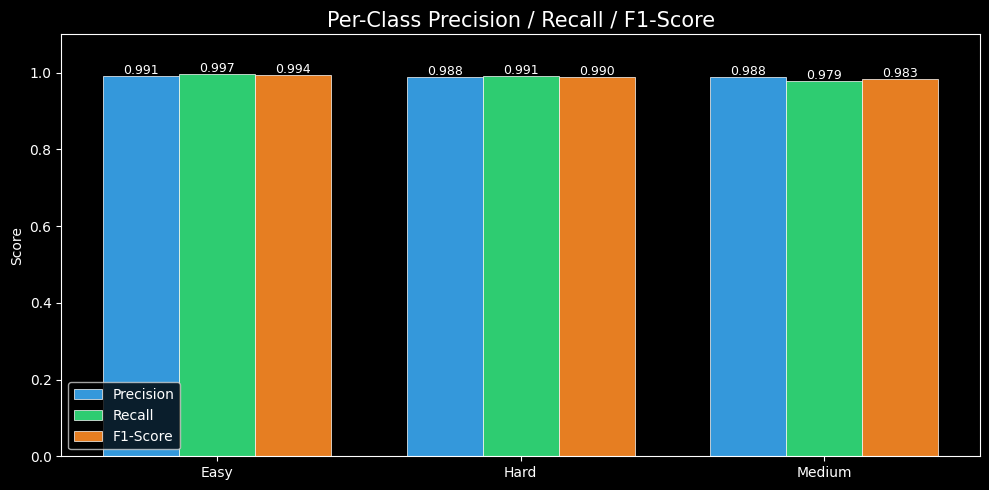

In [6]:
report = classification_report(y_test, y_pred, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score']]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, per_class['precision'], width, label='Precision', color='#3498db', edgecolor='white', linewidth=0.5)
ax.bar(x,         per_class['recall'],    width, label='Recall',    color='#2ecc71', edgecolor='white', linewidth=0.5)
ax.bar(x + width, per_class['f1-score'],  width, label='F1-Score',  color='#e67e22', edgecolor='white', linewidth=0.5)

for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    offset = (i - 1) * width
    for j, val in enumerate(per_class[metric]):
        ax.text(j + offset, val + 0.005, f'{val:.3f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1-Score', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

## 5. ROC Curves (One-vs-Rest)

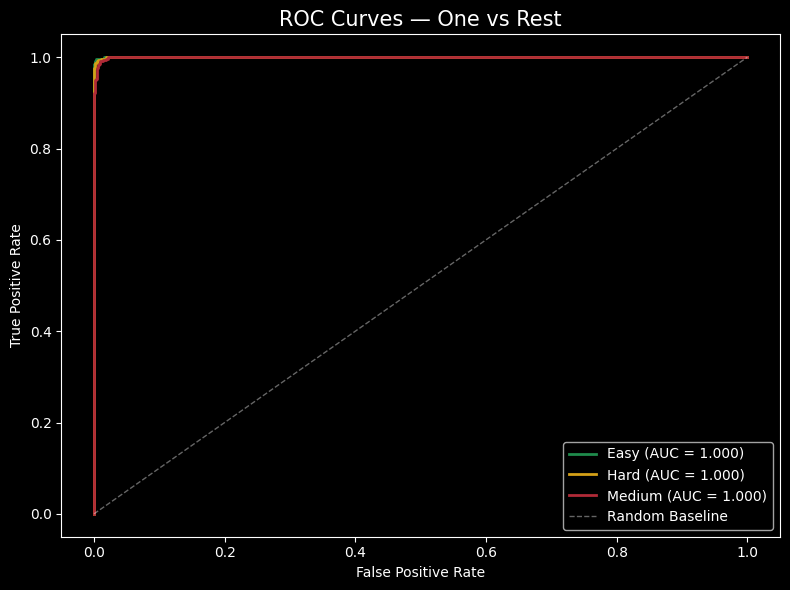

In [7]:
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.4, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One vs Rest', fontsize=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Precision-Recall Curves

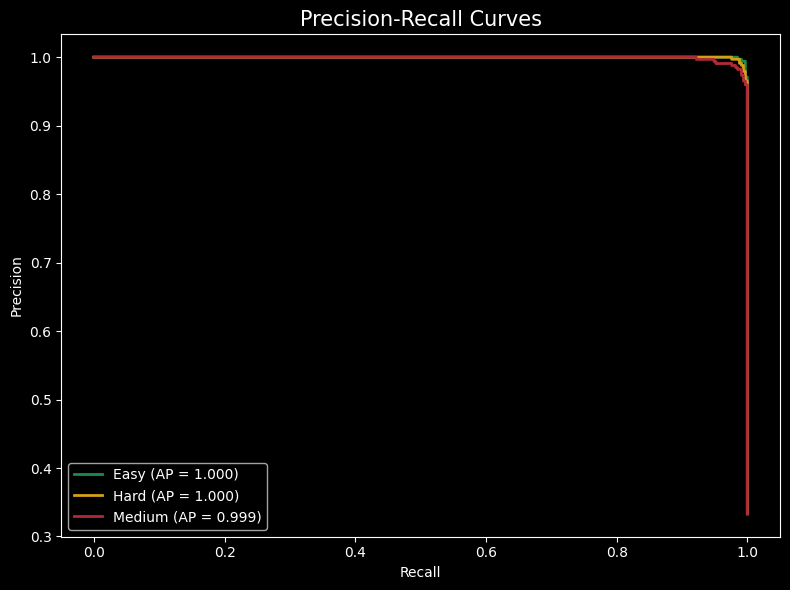

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, CLASS_COLORS)):
    prec_vals, rec_vals, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    ax.plot(rec_vals, prec_vals, color=color, lw=2, label=f'{cls} (AP = {ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=15)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 7. Prediction Confidence Distribution

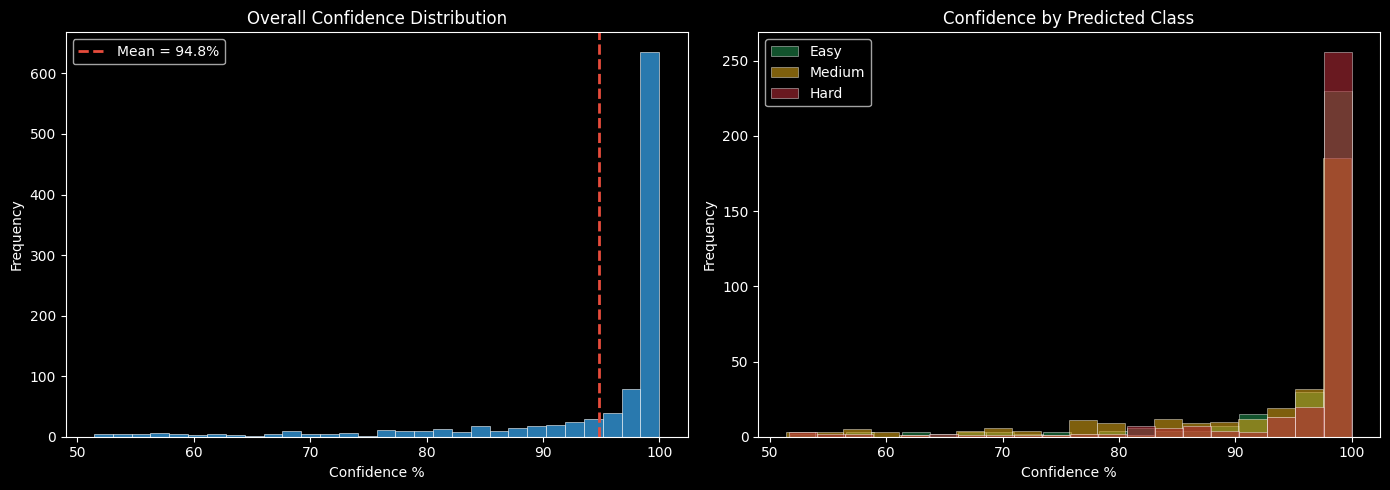

In [9]:
confidence = np.max(y_proba, axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
axes[0].hist(confidence, bins=30, color='#3498db', edgecolor='white', linewidth=0.5, alpha=0.8)
axes[0].axvline(confidence.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Mean = {confidence.mean():.1f}%')
axes[0].set_xlabel('Confidence %')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Confidence Distribution')
axes[0].legend()

# Per-class
for cls, color in COLORS.items():
    mask = y_pred == cls
    if mask.sum() > 0:
        axes[1].hist(confidence[mask], bins=20, alpha=0.6, label=cls,
                     color=color, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Confidence %')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Confidence by Predicted Class')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Correct vs Misclassified Confidence Comparison

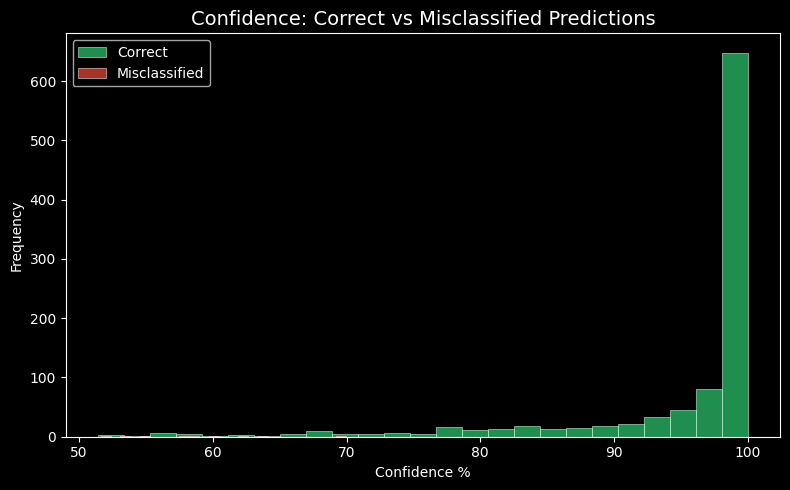

Correct predictions:   mean confidence = 95.25%
Misclassified:         mean confidence = 57.94%


In [10]:
correct_mask = y_pred == y_test.values

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(confidence[correct_mask], bins=25, alpha=0.7, label='Correct', color='#2ecc71', edgecolor='white', linewidth=0.5)
ax.hist(confidence[~correct_mask], bins=25, alpha=0.7, label='Misclassified', color='#e74c3c', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Confidence %')
ax.set_ylabel('Frequency')
ax.set_title('Confidence: Correct vs Misclassified Predictions', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Correct predictions:   mean confidence = {confidence[correct_mask].mean():.2f}%')
print(f'Misclassified:         mean confidence = {confidence[~correct_mask].mean():.2f}%')

## 9. Class Distribution — Train vs Test

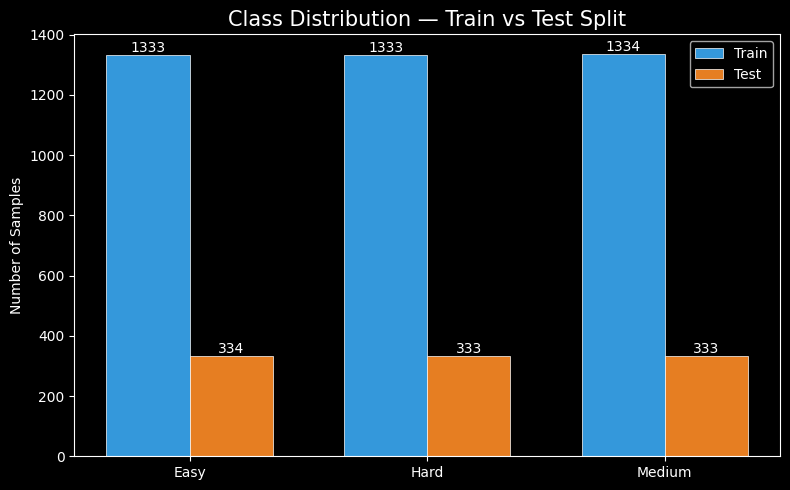

In [11]:
train_counts = y_train.value_counts().reindex(classes)
test_counts = y_test.value_counts().reindex(classes)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, train_counts, width, label='Train', color='#3498db', edgecolor='white', linewidth=0.5)
ax.bar(x + width/2, test_counts,  width, label='Test',  color='#e67e22', edgecolor='white', linewidth=0.5)

for i in range(len(classes)):
    ax.text(i - width/2, train_counts.iloc[i] + 10, str(train_counts.iloc[i]), ha='center', fontsize=10)
    ax.text(i + width/2, test_counts.iloc[i] + 10, str(test_counts.iloc[i]), ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution — Train vs Test Split', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Feature Distributions by Difficulty (Violin Plots)

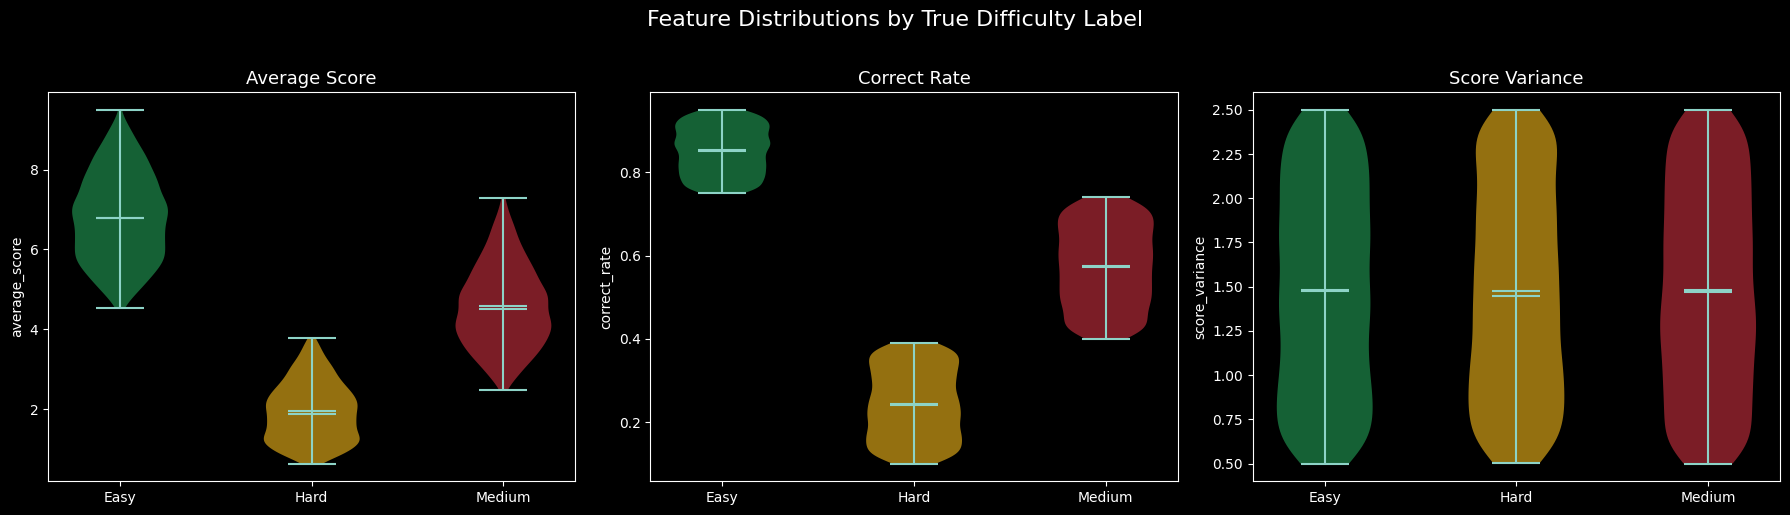

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['average_score', 'correct_rate', 'score_variance']
titles = ['Average Score', 'Correct Rate', 'Score Variance']

for ax, feat, title in zip(axes, features, titles):
    parts = ax.violinplot(
        [df[df['difficulty_label'] == cls][feat].dropna() for cls in classes],
        showmeans=True, showmedians=True
    )
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(CLASS_COLORS[i])
        pc.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(classes)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(feat)

fig.suptitle('Feature Distributions by True Difficulty Label', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 11. Learning Curve

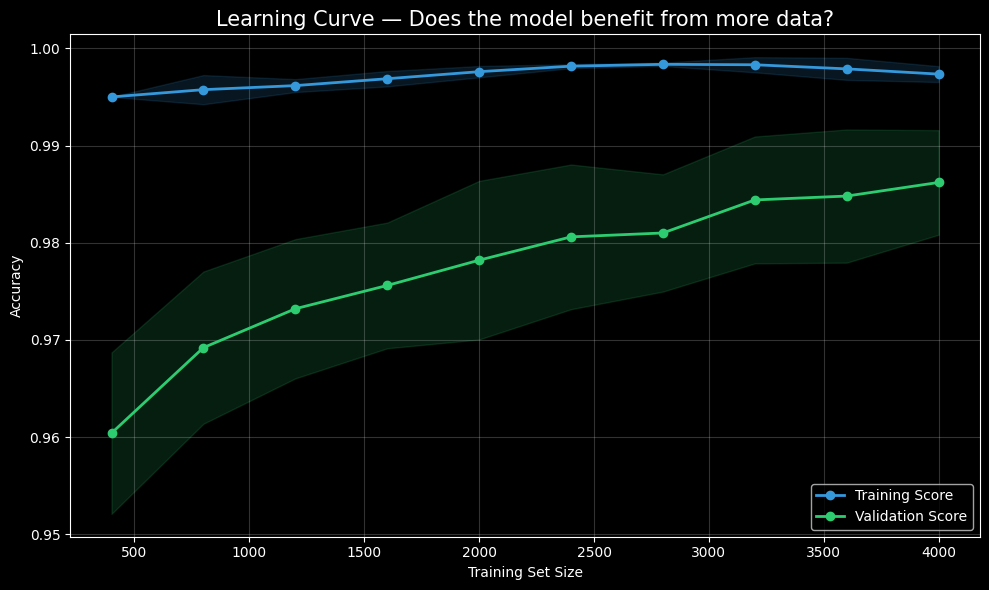

In [13]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2ecc71')
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', lw=2, label='Training Score')
ax.plot(train_sizes, val_mean, 'o-', color='#2ecc71', lw=2, label='Validation Score')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — Does the model benefit from more data?', fontsize=15)
ax.legend(loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 12. Cross-Validation Scores

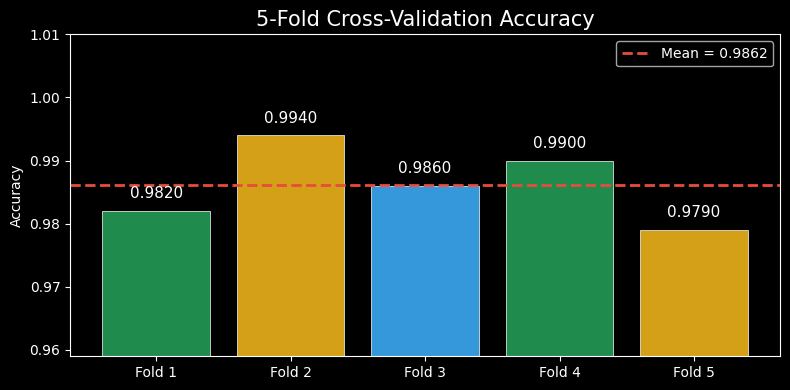

CV Accuracy: 0.9862 ± 0.0054


In [14]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

fig, ax = plt.subplots(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(len(cv_scores))]
bars = ax.bar(folds, cv_scores, color=CLASS_COLORS[:2] + ['#3498db'] + CLASS_COLORS[:2],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11)
ax.axhline(cv_scores.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Mean = {cv_scores.mean():.4f}')
ax.set_ylim(min(cv_scores) - 0.02, 1.01)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

## 13. Misclassification Analysis

Total misclassified: 11 / 1000 (1.10%)

Most common misclassifications:
Actual Predicted  Count
Medium      Hard      4
  Hard    Medium      3
Medium      Easy      3
  Easy    Medium      1



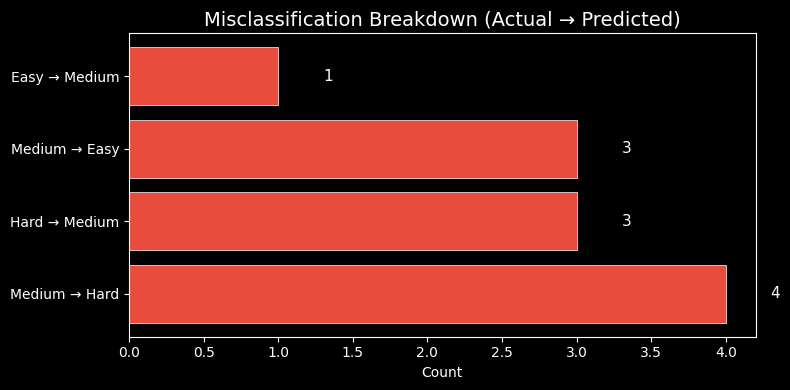

In [15]:
test_df = X_test.copy()
test_df['Actual'] = y_test.values
test_df['Predicted'] = y_pred
test_df['Confidence_%'] = np.max(y_proba, axis=1) * 100
test_df['Correct'] = test_df['Actual'] == test_df['Predicted']

misclassified = test_df[~test_df['Correct']]
print(f'Total misclassified: {len(misclassified)} / {len(test_df)} ({len(misclassified)/len(test_df)*100:.2f}%)')
print()

# Misclassification flow: which classes get confused?
if len(misclassified) > 0:
    error_pairs = misclassified.groupby(['Actual', 'Predicted']).size().reset_index(name='Count')
    error_pairs = error_pairs.sort_values('Count', ascending=False)
    print('Most common misclassifications:')
    print(error_pairs.to_string(index=False))
    print()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    labels = [f'{row.Actual} → {row.Predicted}' for _, row in error_pairs.iterrows()]
    ax.barh(labels, error_pairs['Count'], color='#e74c3c', edgecolor='white', linewidth=0.5)
    for i, val in enumerate(error_pairs['Count']):
        ax.text(val + 0.3, i, str(val), va='center', fontsize=11)
    ax.set_xlabel('Count')
    ax.set_title('Misclassification Breakdown (Actual → Predicted)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications!')

## 14. Score vs Correct Rate — Scatter (Colored by Correctness)

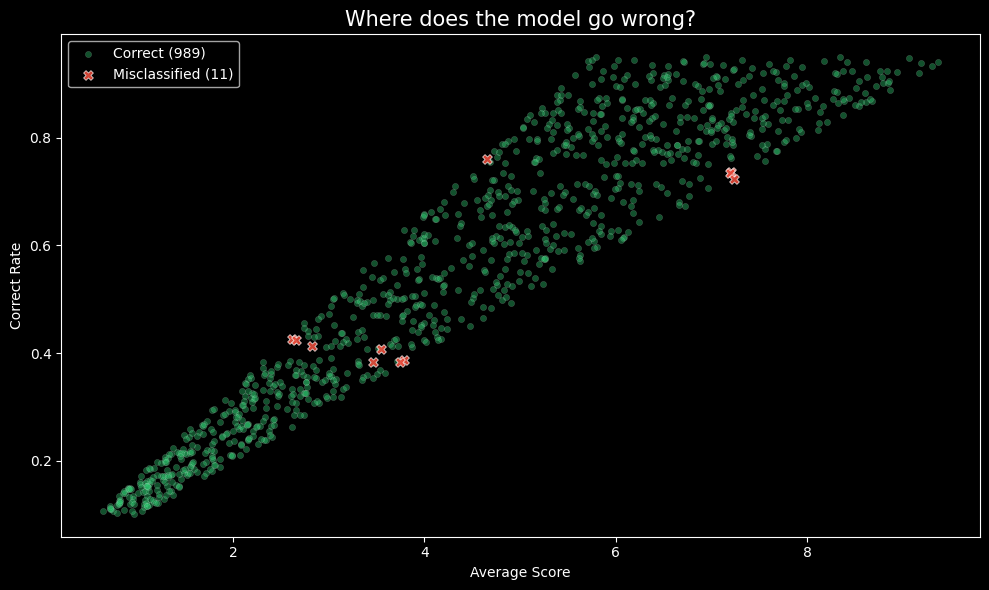

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

correct = test_df[test_df['Correct']]
wrong = test_df[~test_df['Correct']]

ax.scatter(correct['average_score'], correct['correct_rate'],
           alpha=0.4, s=20, color='#2ecc71', label=f'Correct ({len(correct)})', edgecolors='white', linewidth=0.2)
ax.scatter(wrong['average_score'], wrong['correct_rate'],
           alpha=0.9, s=50, color='#e74c3c', label=f'Misclassified ({len(wrong)})',
           edgecolors='white', linewidth=0.5, marker='X')

ax.set_xlabel('Average Score')
ax.set_ylabel('Correct Rate')
ax.set_title('Where does the model go wrong?', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

## 15. Summary
All visualizations above help evaluate the trained Logistic Regression model's performance across:
- **Aggregate metrics** — accuracy, precision, recall, F1
- **Per-class breakdown** — via grouped bar charts and confusion matrices
- **Probabilistic quality** — ROC, PR curves, and confidence distributions
- **Generalization** — learning curve and cross-validation
- **Error analysis** — misclassification patterns and feature-space errors